# == Proyecto 1 Introducción al Reconocimiento de Patrones ==

## Libreta problema 1: Predicción de ingresos, comparación entre implementación propia vs sklearn

**Luis Felipe Jiménez Ulate**/ **Carlos Eduardo Rodríguez Segura**

1. Importación de librerías y funciones del modelo

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# Importar nuestros módulos
from model import (
    # Nueva función optimizada
    get_optimized_custom_models,
    
    # Modelos básicos (para comparación)
    logistic_regression_custom,
    decision_tree_custom,
    logistic_regression_sklearn,
    decision_tree_sklearn,
    
    # Funciones auxiliares
    predecir,
    evaluar_modelo
)


2. Preprocesamiento de datos


Primeras filas del dataset:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   

        occupation   relationship   race     sex  capital.gain  capital.loss  \
0                ?  Not-in-family  White  Female             0          4356   
1  Exec-managerial  Not-in-family  White  Female             0          4356   
2                ?      Unmarried  Black  Female             0          4356   

   hours.per.week native.country income  
0              40  United-States  <=50K  
1              18  United-States  <=50K  
2              40  United-States  <=50K  


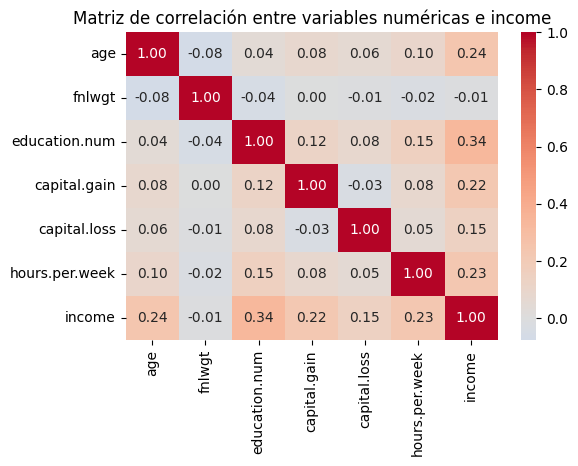


Eliminando 1 variables con baja correlación con income (<0.05): ['fnlwgt']

Características finales usadas en el modelo: 96
Conjunto de entrenamiento: 24129 muestras, 96 características
Conjunto de prueba: 6033 muestras
Características finales seleccionadas: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'marital.status_Married-spouse-absent', 'marital.status_Never-married', 'marital.status_Separated', 'marital.

In [50]:

def preparar_datos(df=None):
    # --------------------------
    # 1. Cargar dataset si no se pasa como argumento
    # --------------------------
    if df is None:
        DATA_PATH = os.path.join("dataset/IngresosPromedioAnual.xlsx")
        df = pd.read_excel(DATA_PATH)

    # --------------------------
    # 2. Mostrar primeras filas completas
    # --------------------------
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    print("\nPrimeras filas del dataset:")
    print(df.head(3))

    # --------------------------
    # 3. Reemplazar "?" por NaN
    # --------------------------
    df.replace("?", pd.NA, inplace=True)

    # --------------------------
    # 4. Eliminar filas con valores faltantes (Tener valores vacíos en ocupación, país de origen y clase de trabajo, afecta a la calidad del análisis)
    # --------------------------
    df.dropna(inplace=True)

    # --------------------------
    # 5. Codificar variable objetivo
    # --------------------------
    df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

    # --------------------------
    # 6. Separar X e y
    # --------------------------
    X = df.drop("income", axis=1)
    y = df["income"]

    # --------------------------
    # 7. Codificar variables categóricas
    # --------------------------
    X = pd.get_dummies(X, drop_first=True)
    #print(df.head(3))
    

    # --------------------------
    # 8. Matriz de correlación completa (solo numéricas)
    # --------------------------
    numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week", "income"]

    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(6,4))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Matriz de correlación entre variables numéricas e income")
    plt.show()

    # --------------------------
    # 9. Eliminar variables poco relacionadas con income
    # --------------------------
    threshold = 0.05  # ajustar umbral mínimo
    corr_with_income = corr_matrix["income"].drop("income")

    to_drop = corr_with_income[abs(corr_with_income) < threshold].index.tolist()

    if to_drop:
        print(f"\nEliminando {len(to_drop)} variables con baja correlación con income (<{threshold}): {to_drop}")
        df = df.drop(columns=to_drop)
    else:
        print("\nNo se eliminaron variables numéricas por baja correlación con income.")



    # --------------------------
    # 10. Escalar variables numéricas
    # --------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --------------------------
    # 11. Dividir en entrenamiento y prueba
    # --------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    """
    age_col = ["age", "income"]
    plt.figure(figsize=(4,2))
    sns.boxplot(data=df[age_col].drop("income", axis=1))
    plt.xticks(rotation=90)
    plt.title("Distribución de las variables numéricas (boxplot)")
    plt.show()
    hour_col = ["hours.per.week", "income"]
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df[hour_col].drop("income", axis=1))
    plt.xticks(rotation=90)
    plt.title("Distribución de las variables numéricas (boxplot)")
    plt.show()
    """

    print(f"\nCaracterísticas finales usadas en el modelo: {X.shape[1]}")
    return X_train, X_test, y_train, y_test, X.columns.tolist()

X_train_base, X_test, y_train_base, y_test, features = preparar_datos()

print(f"Conjunto de entrenamiento: {X_train_base.shape[0]} muestras, {X_train_base.shape[1]} características")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Características finales seleccionadas: {features}")

3. Balanceo de las clases usando undersampling y oversampling al mismo tiempo

In [51]:
import numpy as np

def balancear_medio(X, y):
    """
    Combina oversampling y undersampling para dejar ambas clases en un punto medio.
    """
    # Convertir a NumPy
    X = np.array(X)
    y = np.array(y)

    # Identificar clases
    clases, counts = np.unique(y, return_counts=True)
    mayoritaria = clases[np.argmax(counts)]
    minoritaria = clases[np.argmin(counts)]

    # Índices de cada clase
    idx_mayor = np.where(y == mayoritaria)[0]
    idx_minor = np.where(y == minoritaria)[0]

    # Tamaños
    n_mayor = len(idx_mayor)
    n_minor = len(idx_minor)
    target = (n_mayor + n_minor) // 2  # punto medio

    # Ajustar mayoritaria (undersample si sobra)
    if n_mayor > target:
        idx_mayor_final = np.random.choice(idx_mayor, size=target, replace=False)
    else:
        idx_mayor_final = np.random.choice(idx_mayor, size=target, replace=True)

    # Ajustar minoritaria (oversample si falta)
    if n_minor < target:
        idx_minor_final = np.random.choice(idx_minor, size=target, replace=True)
    else:
        idx_minor_final = np.random.choice(idx_minor, size=target, replace=False)

    # Unir y mezclar
    idx_final = np.concatenate([idx_mayor_final, idx_minor_final])
    np.random.shuffle(idx_final)

    return X[idx_final], y[idx_final]

print("Distribución original en entrenamiento:")
print(np.bincount(y_train_base))

X_train, y_train = balancear_medio(X_train_base, y_train_base)

print("\nDistribución balanceada (punto medio):")
print(np.bincount(y_bal))


Distribución original en entrenamiento:
[18123  6006]

Distribución balanceada (punto medio):
[12064 12064]


4. Entrenamiento básico sin hiperparámetros optimizados

In [52]:
# Modelos custom básicos
log_custom_basic = logistic_regression_custom(X_train, y_train)
tree_custom_basic = decision_tree_custom(X_train, y_train)

# Modelos sklearn básicos
log_sklearn_basic = logistic_regression_sklearn(X_train, y_train)
tree_sklearn_basic = decision_tree_sklearn(X_train, y_train)

5. Optimización de hiperparámetros

In [53]:
# Esta función optimiza sklearn primero, luego usa esos parámetros para la implementación propia
log_custom_opt, tree_custom_opt, log_sklearn_opt, tree_sklearn_opt = get_optimized_custom_models(X_train, y_train)


Optimizando modelos sklearn con GridSearch...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros Logistic Regression: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Mejor score: 0.8192
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Mejores parámetros Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score: 0.8876

Optimizando modelos custom usando parámetros de sklearn como guía...
Optimizando Regresión Logística Propia...
Probando 3 × 2 = 6 combinaciones...
Mejores parámetros Regresión Logística Propia: {'learning_rate': 0.1, 'max_iterations': 2000}
 Score: 0.8210

 Optimizando Árbol de decisión propio usando parámetros de sklearn
Parámetros sklearn encontrados:
max_depth: None
min_samples_split: 2
min_samples_leaf: 1
Parámetros Tree Custom (copiados de sklearn): {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Score: 1.

6. Predicciones en el test set

In [54]:
# Predicciones modelos básicos
pred_log_custom_basic = predecir(log_custom_basic, X_test)
pred_tree_custom_basic = predecir(tree_custom_basic, X_test)
pred_log_sklearn_basic = predecir(log_sklearn_basic, X_test)
pred_tree_sklearn_basic = predecir(tree_sklearn_basic, X_test)

# Predicciones modelos optimizados
pred_log_custom_opt = predecir(log_custom_opt, X_test)
pred_tree_custom_opt = predecir(tree_custom_opt, X_test)
pred_log_sklearn_opt = predecir(log_sklearn_opt, X_test)
pred_tree_sklearn_opt = predecir(tree_sklearn_opt, X_test)

7. Comparación de resultados de implementación propia vs sklearn

In [55]:

def evaluar_modelo(y_true, y_pred):
    """
    Calcula Accuracy, Precision, Recall y F1-score
    usando las fórmulas matemáticas básicas.
    
    y_true : array-like de etiquetas reales (0 o 1)
    y_pred : array-like de predicciones (0 o 1)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcular TP, TN, FP, FN
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    # Fórmulas
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1= 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    

    """Calcula métricas de evaluación con Sklearn para comparación"""
    
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    """

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

def comparar_modelos(y_test, predicciones, nombres_modelos):
    """Compara métricas de múltiples modelos"""
    resultados = []
    
    for pred, nombre in zip(predicciones, nombres_modelos):
        metricas = evaluar_modelo(y_test, pred)
        metricas['modelo'] = nombre
        resultados.append(metricas)
    
    # Crear DataFrame para mejor visualización
    df_resultados = pd.DataFrame(resultados)
    df_resultados = df_resultados[['modelo', 'accuracy', 'precision', 'recall', 'f1_score']]
    
    return df_resultados

def crear_tabla_comparacion(df_resultados):
    """Crea una tabla formateada de resultados"""
    print("\n Tabla de comparación de modelos:")
    print("-" * 80)
    print(f"{'Modelo':<30} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 80)
    
    for _, row in df_resultados.iterrows():
        print(f"{row['modelo']:<30} {row['accuracy']:<12.4f} {row['precision']:<12.4f} {row['recall']:<12.4f} {row['f1_score']:<12.4f}")
    
    print("-" * 80)
    
    # Encontrar el mejor modelo por cada métrica
    mejor_accuracy = df_resultados.loc[df_resultados['accuracy'].idxmax()]
    mejor_f1 = df_resultados.loc[df_resultados['f1_score'].idxmax()]
    
    print(f"\n Mejores modelos:")
    print(f"Mejor Accuracy: {mejor_accuracy['modelo']} ({mejor_accuracy['accuracy']:.4f})")
    print(f"Mejor F1-Score: {mejor_f1['modelo']} ({mejor_f1['f1_score']:.4f})")


# Comparar modelos básicos
print("\n Comparación de modelos con parámetros por defecto")
predicciones_basic = [pred_log_custom_basic, pred_tree_custom_basic, 
                        pred_log_sklearn_basic, pred_tree_sklearn_basic]
nombres_basic = ["Regresión Logística Propia", "Árbol Decisiones Propia",
                "Regresión Logística Sklearn", "Árbol Decisiones Sklearn"]

df_basic = comparar_modelos(y_test, predicciones_basic, nombres_basic)
crear_tabla_comparacion(df_basic)

# Comparar modelos optimizados
print("\n\n Comparación de modelos con parámetros optimizados")
predicciones_opt = [pred_log_custom_opt, pred_tree_custom_opt,
                    pred_log_sklearn_opt, pred_tree_sklearn_opt]
nombres_opt = ["Regresión Logística Propia (Optimizado)", "Árbol Decisiones Propio (Optimizado)",
                "Regresión Logística Sklearn (Optimizado)", "Árbol Decisiones Sklearn (Optimizado)"]

df_opt = comparar_modelos(y_test, predicciones_opt, nombres_opt)
crear_tabla_comparacion(df_opt)


 Comparación de modelos con parámetros por defecto

 Tabla de comparación de modelos:
--------------------------------------------------------------------------------
Modelo                         Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Regresión Logística Propia     0.7822       0.5374       0.8995       0.6728      
Árbol Decisiones Propia        0.8086       0.5773       0.8628       0.6918      
Regresión Logística Sklearn    0.8173       0.5924       0.8535       0.6994      
Árbol Decisiones Sklearn       0.8107       0.5811       0.8589       0.6932      
--------------------------------------------------------------------------------

 Mejores modelos:
Mejor Accuracy: Regresión Logística Sklearn (0.8173)
Mejor F1-Score: Regresión Logística Sklearn (0.6994)


 Comparación de modelos con parámetros optimizados

 Tabla de comparación de modelos:
------------------------------------------

8. Gráficas importantes

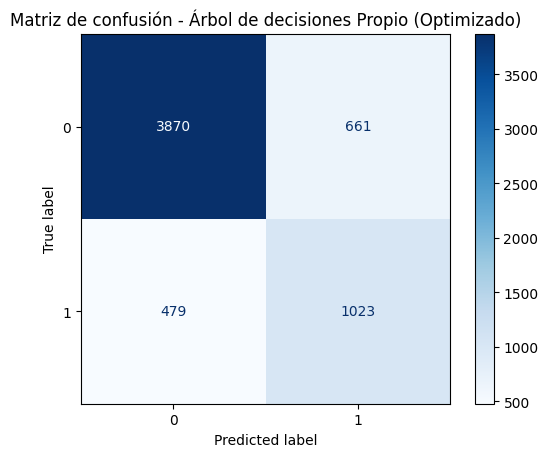

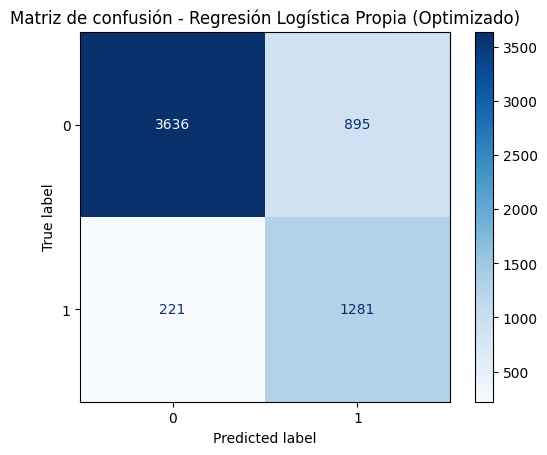

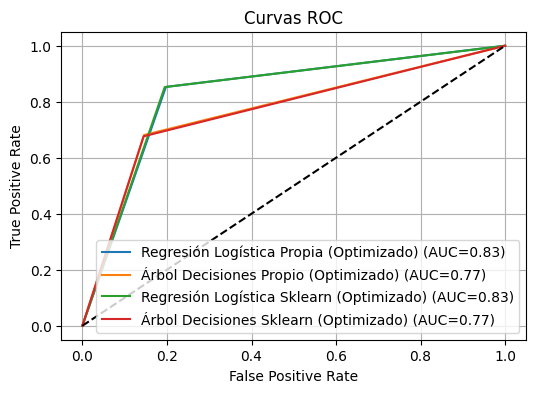

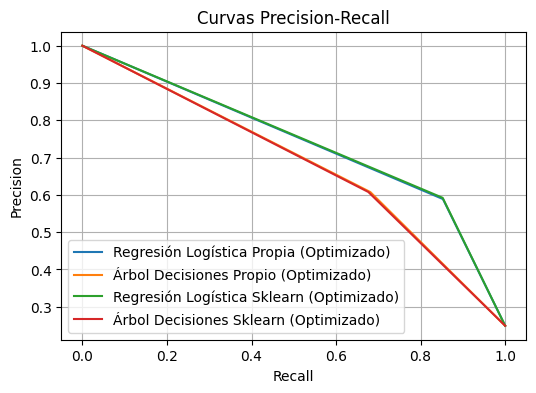

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, classification_report

def graficar_confusion(y_true, y_pred, nombre_modelo):
    """Muestra la matriz de confusión"""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

def graficar_roc(y_true, predicciones, nombres):
    """Grafica curvas ROC para varios modelos"""
    plt.figure(figsize=(6,4))
    for pred, nombre in zip(predicciones, nombres):
        fpr, tpr, _ = roc_curve(y_true, pred)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

def graficar_precision_recall(y_true, predicciones, nombres):
    """Grafica curvas Precision-Recall"""
    plt.figure(figsize=(6,4))
    for pred, nombre in zip(predicciones, nombres):
        precision, recall, _ = precision_recall_curve(y_true, pred)
        plt.plot(recall, precision, label=nombre)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curvas Precision-Recall")
    plt.legend()
    plt.grid(True)
    plt.show()


# Matriz de confusión para el mejor modelo optimizado
graficar_confusion(y_test, pred_tree_custom_opt, "Árbol de decisiones Propio (Optimizado)")
graficar_confusion(y_test, pred_log_custom_opt, "Regresión Logística Propia (Optimizado)")

# Curvas ROC para todos los modelos optimizados
graficar_roc(y_test, predicciones_opt, nombres_opt)

# Curvas Precision-Recall
graficar_precision_recall(y_test, predicciones_opt, nombres_opt)


